<a href="https://colab.research.google.com/github/stefanogiagu/corso_AI_2026/blob/main/MetodiAI_2026_E9_CNN_RICH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metodi AI per La Fisica 2026

## Esercitazione E9: allenamento end-to-end di un modello ANN shallow e di una CNN per la classificazione di eventi in un rivelatore RICH in fisica delle particelle


V2.0 - Stefano Giagu <stefano.giagu@uniroma1.it>

**Identificazione di particelle con rivelatri RICH**

**Task**: stimare il numero di particelle cariche e il numero di elettroni per ogni eventi ricortuito con il revelatore RICH dell'esperiemtno NA62 al CERN

Descrizione del rivelatore RICH: [link](https://na62.web.cern.ch/DetectorBeam/RICH.html)

Il rivelatore RICH (Ring Imaging CHerenkov) dell’esperimento NA62 è progettato per identificare particelle cariche (in particolare distinguere pioni da muoni) misurando la radiazione Čerenkov emessa quando attraversano un mezzo. Quando una particella carica attraversa il gas (nel caso di NA62, neon) con velocità maggiore della velocità della luce nel mezzo, emette radiazione Čerenkov sotto forma di un cono di luce. Questo cono, proiettato sul piano dei rivelatori di luce (fotomoltiplicatori (PMT)), genera un anello luminoso, con raggio legato all’angolo Čerenkov e quindi alla velocità della particella. Il goal è quello di identificare il numero di anelli presenti nel rivelatore.

**Input:** i dati del rivelatore RICH sono rappresentati come immagini di shape $[N,16,16]$, in cui ogni pixel indica il numero di hit misurati dai PMT in una certa zona geometrica del rivelatore. Gli eventi possono avere 0,1,2 e 3+ anelli. Le label di classe sono date in un vettore numpy di label in formato one-hot (eg. classe 1 -> [0,1,0,0], classe 3 -> [0,0,0,1] etc.).

Vogliamo addestrare una rete neurale di tipo Convoluzionale, a predire quanti tipi di anelli sono presenti in una data immagine.



In [29]:
# crea il folder data e download il dataset
import os

success = os.path.exists("data")
if not success:
  os.makedirs("data")

success = os.path.exists("data/x_all_08011.npy")
if not success:
  !wget http://giagu.web.cern.ch/giagu/CERN/x_all_08011.npy -P data/
  !wget http://giagu.web.cern.ch/giagu/CERN/y_all_08011.npy -P data/

In [30]:
!ls -lh  data/

total 40M
-rw-r--r-- 1 root root  40M May  3 15:07 x_all_08011.npy
-rw-r--r-- 1 root root 626K May  3 15:06 y_all_08011.npy


**Leggiamo i dati, controlliamo il formato (shape), e plottiamo un esempio di immagine**

*   i dati sono in formato numpy, possono essere letti con la funzione *np.load*
*   printiamo la shape dei vettori numpy letti e il tipo di variabile
*   usiamo matplotlib *plt.imshow()* o *plt.matshow* per plottare un elemento dell array



In [31]:
import numpy as np


x_all = np.load('data/x_all_08011.npy')
y_all = np.load('data/y_all_08011.npy')

print('Shape immagini: ',x_all.shape)
print('Shape label: ',y_all.shape)
print('Tipo immagini: ', x_all.dtype)
print('Tipo label: ', y_all.dtype)

Shape immagini:  (20000, 16, 16)
Shape label:  (20000, 4)
Tipo immagini:  float64
Tipo label:  float64


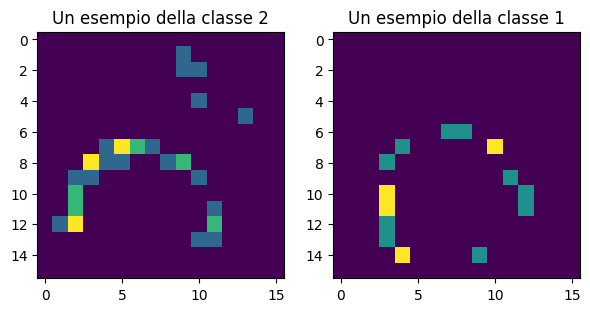

In [32]:
import matplotlib.pyplot as plt

# plottiamo due immagini idx=0 e idx=10
idx1 = 0
idx2 = 10
plt.figure(figsize=(7,5))
plt.subplot(1,2,1)
plt.imshow(x_all[idx1,:,:])
plt.title("Un esempio della classe {}".format(np.argmax(y_all[idx1])))
plt.subplot(1,2,2)
plt.imshow(x_all[idx2,:,:])
plt.title("Un esempio della classe {}".format(np.argmax(y_all[idx2])))
plt.show()

**Analisi delle immagini**

plottiamo l'istogramma dell'intensità media per classe delle immagini. Costruiamo una funzione atta allo scopo

deve essere [N,1] :  (20000,)


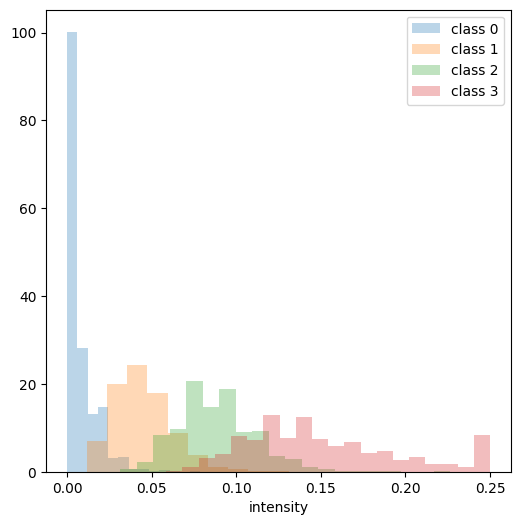

In [33]:
def plot_histointensity(x, y):

  classes = np.argmax(y, axis=1) #ritorna l'indice del massimo valore di un array lungo la dimensione axis

  intensities = x.reshape(x.shape[0],-1).mean(axis=1) # [N,16,16] -> [N,16*16] e poi fa la media lungo la dimensione axis (axis=1 -> secnodna dimensione)
  print("deve essere [N,1] : ",intensities.shape)

  f,ax = plt.subplots(1,1,figsize=(6,6))
  for c in [0,1,2,3]:
    ax.hist(intensities[classes==c],20,alpha=0.3,label="class {}".format(c),density=True)

  ax.set_xlabel("intensity")
  ax.legend()

plot_histointensity(x_all, y_all)

deve essere [N,1] :  (18402,)


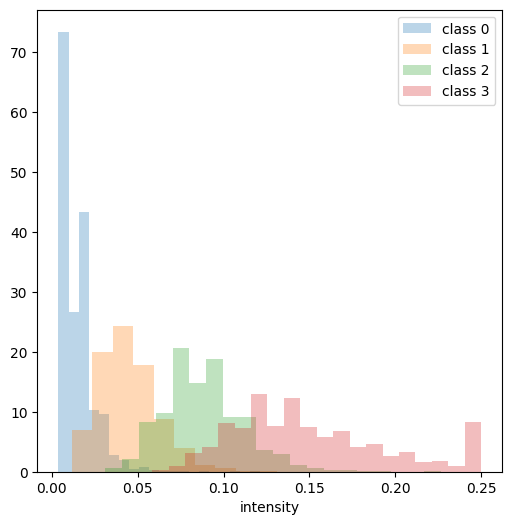

In [34]:
# rimuoviamo le immagini totalmente vuote (non sono utili, qualsiasi operazione su un array di zeri è banale, inoltre già sappiamo che nessun segnale significa nessuna particella

def remove_empty(x, y):
  intensities = x.reshape(x.shape[0],-1).sum(axis=1)
  y_tmp = y[intensities>0]
  x_tmp = x[intensities>0]
  return x_tmp, y_tmp

x_all, y_all = remove_empty(x_all, y_all)
plot_histointensity(x_all, y_all)

**Analisi delle immagini**

plottiamo la distribuzione delle classi son un istogramma a torta

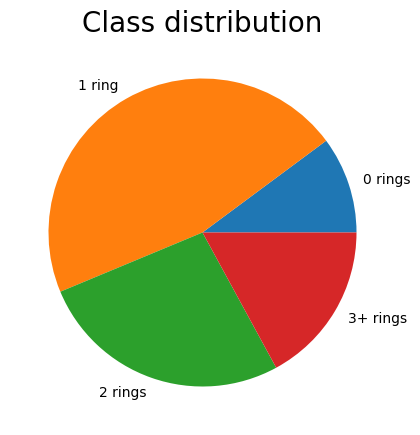

In [35]:
# definiamo la finzione piechartclasses

def piechartclasses(y):
  classes = np.argmax(y, axis=1)
  c = np.unique(classes) #ritorna gli elementi unici di un array (ordinati)
  arr_c = [np.mean(classes==i) for i in c]


  fig = plt.figure(figsize =(8, 5))
  plt.pie(arr_c, labels = ["0 rings", "1 ring", "2 rings", "3+ rings"])
  plt.title("Class distribution",fontsize=20)
  plt.show()

piechartclasses(y_all)

**Convertiamo i dati in tensori torch, creiamo dataset e dataloader e facciamo data-augmentation**

In [36]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.utils.data as data

# data augmentation (eg applichiamo trasformazioni ai dati che non cambiano "la fisica" del problema, per mostrare alla rete eneurale una maggiore varietà di esempi, in modo da aumentarne la capacità di generalizzazione)

# rimozione di un hit
def remove_a_hit(image):
  if image.sum()<3:
    return image
  a,b = np.nonzero(image) # ritorna due vettori (uno per ogni dimensione) corrispondenti agli elementi non zero
  i = np.random.randint(0,len(a))
  image[a[i],b[i]] -=1
  return image

# affiunge un hit
def add_a_hit(image):
  image[np.random.randint(0,16),np.random.randint(0,16)] +=1
  return image

# flip tutti gli hit
def flip_hit(image):
  if np.random.rand()>0.5:
    image= np.fliplr(image) #rovescia l'ordine degli elementi lungo left-right
  else:
    image= np.flipud(image)  #rovescia l'ordine degli elementi lungo up-down
  return image

# sovrappone due immagini
def sum_images(image,lab,image2,lab2):
  lab=np.argmax(lab)
  lab2=np.argmax(lab2)
  image = image + image2
  lab = lab + lab2
  if lab>3:
    lab=3
  lab_tmp = np.zeros(4)
  lab_tmp[lab]=1

  return image,lab_tmp


# creiamo una Dataset in torch. In questo esempio non usiamo i semplici Dataset usati negli esempi precedenti perché vogliamo
# applicare alcune trasformazioni "custom" ai dati, utili per l'addestramento.

# lo scopo del data Generator è quello di generare minibatch + fare data augmentation

class HitImageGenerator(Dataset): #la classe eredità dalla classe di pyTorch Dataset (eg estende le funzionalità di Dataset)
    def __init__(self, X, y, AUGMENT=False):
        self.X = X
        self.y = y
        self.AUGMENT = AUGMENT

    def __len__(self): #ritorna la dimensione del dataset
        return len(self.X)

    def __getitem__(self, idx): #ritorna l'elemento idx del dataset
        image = self.X[idx]
        label = self.y[idx]
        iclass = np.argmax(label)

        if self.AUGMENT: # applica data augmentation (da usare solo in training)
          if iclass >1:
            if np.random.rand()>1:  # >1 per disabilitare questa augmentation che non è molto utile nel nostro caso
              image = remove_a_hit(image)
          if np.random.rand()>1:    # >1 per disabilitare questa augmentation che non è molto utile nel nostro caso
            image = add_a_hit(image)
          if np.random.rand()>0.5:  # questa è utile
            image = flip_hit(image)
          if np.random.rand()>0.85: # anche questa è utile
            id2=np.random.randint(len(self.X))
            image2 = self.X[id2]
            lab2 = self.y[id2]
            image, label = sum_images(image,label,image2,lab2)


        image = image/image.sum()  #normalizzazione
        tensor_image = torch.from_numpy(image).unsqueeze(dim=0).float() # converte in torch tensor e fa reshaping
        # NOTA: Convolution layers in pyTorch si aspettano tensori con shape (B, C, m, n), in cui C è il numero di canali di colore. In questo caso C=1. unsqueeze(0) aggiungee una dimensione dummy in posizione dim
        # 16, 16) -> (1, 16, 16)
        tensor_label = torch.from_numpy(label).float() # converte in torch tensor
        return tensor_image, tensor_label

# costruiamo anche un DataLoader custom, che permetta di bilanciare le classi facendo un oversampling delle classi minoritarie in modo da evitare bias nell'addestramento
# del modello (se una calsse e' preponderante il modello può non imparare bene e ceracre di predire in modo naive solo la classe maggioritaria)

# NOTA: e' anche possibile calcolare a priori i pesi di ogni classe, e poi pesare la funzione di loss a seconda della classe che si stà utilizzando (questo è l'approccio più suato perché più semplice,
# qui per ragioni didattiche vi faccimo vedere come si può fare a livello di campionamento "bilanciato" del dataset)

class BalancedDataLoader(DataLoader): #eredita da pytorch DataLoader
    def __init__(self, dataset, batch_size=1, shuffle=True):
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle

        # conta il numero di eventi in cascuna classe
        class_counts = torch.bincount(torch.tensor(np.argmax(dataset.y,axis=1)))

        # calcola il peso di ciascun evento (1/frazione della classe nel dataset)
        weights = 1.0 / class_counts[np.argmax(dataset.y, axis=1)] # ha la stessa lunghezza del array dei dati

        # crea un campionatore che campiona ogni classe con eguale probabilità
        sampler = torch.utils.data.sampler.WeightedRandomSampler(weights, len(weights))

        super().__init__(dataset, batch_size=batch_size, sampler=sampler)

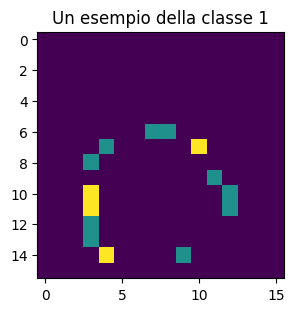

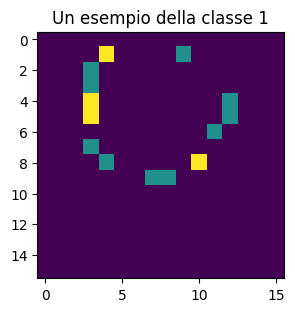

In [37]:
# plottiamo un esempio di data augmentation

def plot_example(image,lab):
  plt.figure(figsize=(7,5))
  plt.subplot(1,2,1)
  plt.imshow(image)
  plt.title("Un esempio della classe {}".format(np.argmax(lab)))
  plt.show()

image = x_all[10,:,:]
lab = y_all[10]
plot_example(image,lab)
plot_example(flip_hit(image),lab)

In [38]:
# splittiamo ora il dataset e creiamo i dataset e dataloader

from sklearn.model_selection import train_test_split
X, X_test, y, y_test = train_test_split(x_all, y_all, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

train_dataset = HitImageGenerator(X_train, y_train, AUGMENT=True)
train_loader = BalancedDataLoader(train_dataset, batch_size=128, shuffle=True)

val_dataset = HitImageGenerator(X_val,y_val)
val_loader = BalancedDataLoader(val_dataset, batch_size=128, shuffle=False)

test_dataset = HitImageGenerator(X_test,y_test)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) #non usiamo il balanced generator per il test. (evita leaks dal training set)

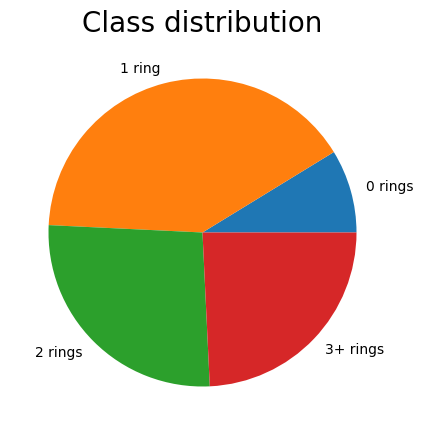

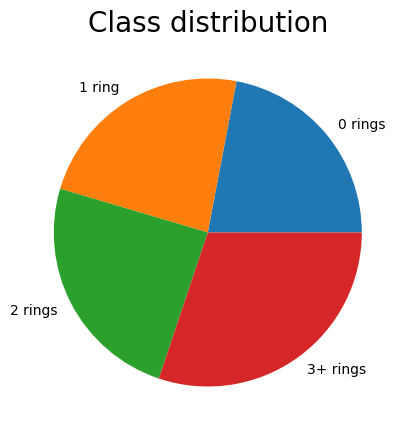

In [39]:
# controlliamo che il balancing stia funzionando

balanced  =[]
notbalanced=[]
tmp_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
for _,lab in train_loader:
  balanced.extend(lab.numpy())
for _,lab in tmp_loader:
  notbalanced.extend(lab.numpy())

piechartclasses(notbalanced)    #con dataloader non bilanciato
piechartclasses(balanced)       #con dataloader bilanciato

**Modello Convoluzionale**

Implementiamo un'architettura VGG-like con convoluzioni 2x2 (le immagini di input sono piccole)

In [40]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # nn.Conv2d(in_channles, out_channels, kernel_size, stride=1, padding=0, ...)
        # usiamo kernel 2x2, stride=1, no-padding (eg padding=0)

        # primo blocco convoluzionale
        self.conv1_1 = nn.Conv2d(1,16, 2)   #16 filtri 2x2: # parametri 16 * 2 * 2 + 16 = 80 parametri,  input (B,1,16,16) -> output (B, 16, 16-2+1=15, 15)
        self.conv1_2 = nn.Conv2d(16,16, 2)  # (B, 16, 15, 15) -> (B, 16, 14, 14)
        self.conv1_3 = nn.Conv2d(16,32, 2)  # (B, 16, 14, 14) -> (B, 32, 13, 13)
        self.pool = nn.MaxPool2d(2, 2)      # (B, C, m, n) -> (B, C, m/2, n/2) eg  (B, 32, 13, 13) ->  (B, 32, 6, 6)

        # secondo blocco convoluzionale
        self.conv2_1 = nn.Conv2d(32, 32, 2)
        self.conv2_2 = nn.Conv2d(32, 64, 2)
        self.conv2_3 = nn.Conv2d(64, 64, 2)

        # head di classificazione
        self.fc1 = nn.Linear(64 , 64) # 64*64 + 64 parametri
        self.fc2 = nn.Linear(64, 64)
        self.dropout1 = nn.Dropout(p=0.3)
        self.fc3 = nn.Linear(64,4)

    def forward(self, x):
       x = self.conv1_1(x)
       x = F.relu(x)
       x = self.conv1_2(x)
       x = F.relu(x)
       x = self.conv1_3(x)
       x = F.relu(x)
       x = self.pool(x)
       x =F.relu(self.conv2_1(x))
       x =F.relu(self.conv2_2(x))
       x = self.pool(F.relu(self.conv2_3(x)))

       x = torch.flatten(x, 1) # appiattisce tutte le dimensioni tranne il batch (B,c,m,n) -> (B,c*m*n)

       x = F.relu(self.fc1(x))
       x = self.dropout1(x)
       x = F.relu(self.fc2(x))
       x = self.dropout1(x)
       x = self.fc3(x)        # non serve applicare softmax in uscita perché in pytorch lo fa automaticamente la crossentropy

       return x

# instanziamo un modello (crea il modello e inizializza i pesi)
model = Net()

In [41]:
# in torch/pytorch dati e modelli devono essere mossi sull'unità di calcolo che si vuole utilizzare (cpu e GPU)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print('Using',device, 'device')

Using cuda device


In [42]:
# printiamo la struttura del modello

print(model)

from torchsummary import summary
if torch.cuda.is_available():
  summary(model.cuda(), input_size=(1,16,16))
else:
  summary(model, input_size=(1,16,16))

Net(
  (conv1_1): Conv2d(1, 16, kernel_size=(2, 2), stride=(1, 1))
  (conv1_2): Conv2d(16, 16, kernel_size=(2, 2), stride=(1, 1))
  (conv1_3): Conv2d(16, 32, kernel_size=(2, 2), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2_1): Conv2d(32, 32, kernel_size=(2, 2), stride=(1, 1))
  (conv2_2): Conv2d(32, 64, kernel_size=(2, 2), stride=(1, 1))
  (conv2_3): Conv2d(64, 64, kernel_size=(2, 2), stride=(1, 1))
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=64, out_features=4, bias=True)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 15, 15]              80
            Conv2d-2           [-1, 16, 14, 14]           1,040
            Conv2d-3           [-1, 32, 13, 13]    

In [43]:
#install torchmetrics: collezione di metriche (accuracy etc.) facili da utilizzare
!pip install torchmetrics

In [44]:
# loss, metriche, optimizer

model = Net()
model.to(device) #muove il modello sulla device di calcolo

import torch.optim as optim

criterion = nn.CrossEntropyLoss() #standard per classificazione

# metrics (accuracy)
import torchmetrics
from torchmetrics.classification import Accuracy

metric = Accuracy(task="multiclass", num_classes=4)
metric = metric.to(device) #NOTE: deve essere spostata sulla devide di calcolo (torch lo fa automatcamente solo con le sue loss)


optimizer = optim.Adam(model.parameters(), lr=0.003)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95) #aggiungiamo anche uno scheduler che cdimnusice il lr con il numero di epoche secondo una legge esplonenziale)

In [45]:
# testiamo l'implementazione su un batch per verificare che tutto funzioni

xb,yb = next(iter(train_loader))

xb=xb.type(torch.float).to(device) #sposta i tensori sulla device
yb=yb.type(torch.float).to(device)

# predizione (semplicemnte chiamare il NN come una funzione)

pred = model(xb)
print('output shape: ', pred.shape)
print('target shape: ', yb.shape)

# loss e metrica
loss = criterion(pred, yb)
metric.reset()
metric.update(pred, torch.argmax(yb, axis=1)) #ricorda i targets sono in formato one-hot (così estraggo la classe)

print('loss: ', loss.item())
print('accuracy: ',  metric.compute().item())

output shape:  torch.Size([128, 4])
target shape:  torch.Size([128, 4])
loss:  1.3967132568359375
accuracy:  0.171875


In [46]:
# Define the number of epochs and the patience for early stopping
num_epochs = 120
patience = 20

# Initialize the variables for tracking the best validation accuracy and the number of epochs since the best accuracy
best_val_acc = 0.0
epochs_since_best_val_acc = 0
best_epoch = 0
best_weights = None

# Initialize lists to store the training and validation curves

train_curve=[]
val_curve=[]
lr_curve=[]

# Train loop
for epoch in range(num_epochs):# the network train on all the elements
    # Training
    model.train()
    tmp_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader): # divide the problem in batches
        # Forward pass

        data=data.type(torch.float).to(device) #sposta i tensori sulla device
        target=target.type(torch.float).to(device)

        output = model(data) #output will be something [batch,4]
        loss = criterion(output, target)

        # Backward pass and optimization
        optimizer.zero_grad()# clear the previous gradients
        loss.backward()# compute gradient of loss
        optimizer.step()# update the weigths

        tmp_loss += loss.item()

    if epoch > 20:
     scheduler.step()

    lr_curve.append(optimizer.param_groups[0]['lr'])
    train_curve.append(tmp_loss/len(train_loader))
    # Validation
    model.eval() # the validation step do NOT change the parameters
    metric.reset()
    with torch.no_grad():
        val_total = 0
        val_loss = 0

        for data, target in val_loader:
            data=data.type(torch.float).to(device) #sposta i tensori sulla device
            target=target.type(torch.float).to(device)
            output = model(data)
            val_loss += criterion(output, target).item()

            metric.update(output, torch.argmax(target, axis=1))

        val_loss /= len(val_loader)
        val_curve.append(val_loss)

        val_acc = metric.compute().item()

        print(f"Epoch {epoch+1}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}, lr: {optimizer.param_groups[0]['lr']:.3e}")

        # Check if the validation accuracy has improved
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_since_best_val_acc = 0
            best_weights = model.state_dict()
            torch.save(best_weights, 'best_weights.pth')
            print("Best!")
            best_epoch = epoch
        else:
            epochs_since_best_val_acc += 1

        # Check if early stopping is necessary
        if epochs_since_best_val_acc >= patience:
            print("Early stopping!")
            break



Epoch 1, Validation Loss: 1.3880, Validation Accuracy: 0.2533, lr: 3.000e-03
Best!
Epoch 2, Validation Loss: 1.3913, Validation Accuracy: 0.2537, lr: 3.000e-03
Best!
Epoch 3, Validation Loss: 1.3931, Validation Accuracy: 0.2591, lr: 3.000e-03
Best!
Epoch 4, Validation Loss: 1.3852, Validation Accuracy: 0.2557, lr: 3.000e-03
Epoch 5, Validation Loss: 0.9116, Validation Accuracy: 0.6513, lr: 3.000e-03
Best!
Epoch 6, Validation Loss: 0.8015, Validation Accuracy: 0.6886, lr: 3.000e-03
Best!
Epoch 7, Validation Loss: 0.6683, Validation Accuracy: 0.7165, lr: 3.000e-03
Best!
Epoch 8, Validation Loss: 0.5807, Validation Accuracy: 0.7365, lr: 3.000e-03
Best!
Epoch 9, Validation Loss: 0.5923, Validation Accuracy: 0.7552, lr: 3.000e-03
Best!
Epoch 10, Validation Loss: 0.5419, Validation Accuracy: 0.7569, lr: 3.000e-03
Best!
Epoch 11, Validation Loss: 0.5954, Validation Accuracy: 0.7423, lr: 3.000e-03
Epoch 12, Validation Loss: 0.6183, Validation Accuracy: 0.7409, lr: 3.000e-03
Epoch 13, Validatio

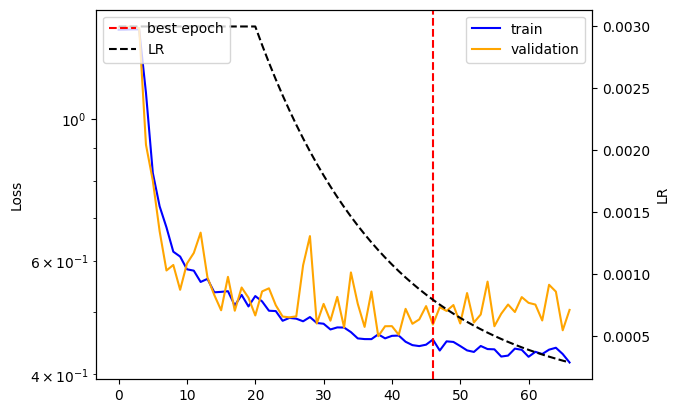

In [47]:
# plot delle curve di addestramento

f,ax = plt.subplots(1,1)
ax2 = ax.twinx()
ax.plot(train_curve,label="train",color="blue")
ax.plot(val_curve,label="validation",color="orange")
ax2.axvline(best_epoch,color="r",linestyle="--",label="best epoch")
ax.legend(loc=1)
ax.set_ylabel("Loss")


ax2.plot(lr_curve,"k--",label="LR",)
ax2.legend(loc=2)
plt.xlabel("Epochs")
ax2.set_ylabel("LR")
ax.set_yscale("log")

In [48]:
# carichiamo i pesi del best model
model=Net()
model.load_state_dict(torch.load('best_weights.pth'))
model.eval()

Net(
  (conv1_1): Conv2d(1, 16, kernel_size=(2, 2), stride=(1, 1))
  (conv1_2): Conv2d(16, 16, kernel_size=(2, 2), stride=(1, 1))
  (conv1_3): Conv2d(16, 32, kernel_size=(2, 2), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2_1): Conv2d(32, 32, kernel_size=(2, 2), stride=(1, 1))
  (conv2_2): Conv2d(32, 64, kernel_size=(2, 2), stride=(1, 1))
  (conv2_3): Conv2d(64, 64, kernel_size=(2, 2), stride=(1, 1))
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=64, out_features=4, bias=True)
)

In [49]:
# calcolo e plot della matrice di confusione sul test set

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

def test_model(model, test_loader):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, targets in test_loader:

            outputs = model(inputs)
            targets = targets.numpy()
            outputs = outputs.numpy()

            predicted = np.argmax(outputs, 1)
            targets = np.argmax(targets , 1)

            y_true.extend(targets)
            y_pred.extend(predicted)

    cm = confusion_matrix(y_true, y_pred,normalize="true")

    return np.array(y_true), np.array(y_pred), cm


_,_,cm=test_model(model, test_loader)

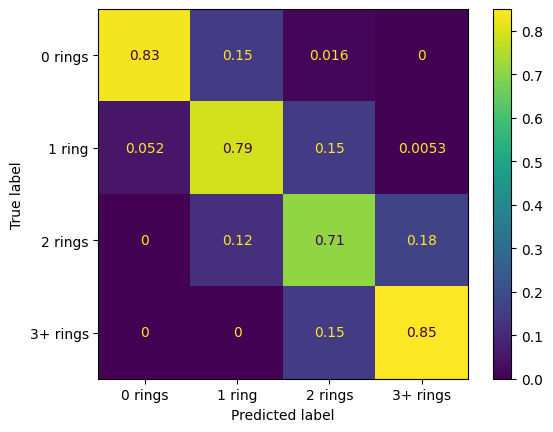

In [50]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0 rings", "1 ring", "2 rings", "3+ rings"])
disp.plot()
plt.show()